In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.utils.paths import load_paths
from src.utils.logging import setup_logger
from src.models.ensemble import create_ensemble
# CHANGED: Use sklearn metrics directly
import sklearn.metrics as skm
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_fscore_support, confusion_matrix
from src.eval.plots import plot_roc_curves, plot_pr_curves, plot_confusion_matrices, plot_probability_distributions
from src.eval.evaluate import print_metrics_summary
from src.eval.calibration import fit_calibrator_from_df

paths = load_paths()
logger = setup_logger(level="INFO")

# 1. Create and Evaluate the Ensemble
# This assumes that XGBoost, LightGBM, and CatBoost have already been trained
# and their preds.parquet files exist in artifacts/
logger.info("Creating and Evaluating Ensemble...")
ens_res = create_ensemble(paths=paths, ensemble_yaml=paths.configs_dir / "ensemble.yaml")
print_metrics_summary(ens_res.metrics)

# NOTE: Calibration is now handled INSIDE create_ensemble.
# The output parquet contains 'p_calib' directly.
df_preds = pd.read_parquet(ens_res.preds_path)
# No need to alias p_raw -> p_calib, as p_calib already exists.


2026-03-04 04:09:00 | INFO | ai-vpn-firewall | Creating and Evaluating Ensemble...
Ensemble Weights: {'xgb': 0.33349606212983723, 'lgbm': 0.33300787574032553, 'catboost': 0.33349606212983723}
Calibrating Ensemble...

EVALUATION SUMMARY
Global Threshold: 0.5

--- Raw Probabilities ---

Split: TRAIN
  N: 16138 (Pos: 2378, Neg: 13760)
  ROC AUC: 0.9999992970935123
  PR AUC:  0.9999959498665018
  At Threshold 0.5:
    Precision: 0.9798104655953852
    Recall:    1.0
    F1 Score:  0.9898022892819979
    Confusion Matrix: TN=13711, FP=49, FN=0, TP=2378

Split: TEST
  N: 1844 (Pos: 251, Neg: 1593)
  ROC AUC: 0.999155918698089
  PR AUC:  0.9940014845076514
  At Threshold 0.5:
    Precision: 0.9725490196078431
    Recall:    0.9880478087649402
    F1 Score:  0.9802371541501976
    Confusion Matrix: TN=1586, FP=7, FN=3, TP=248

Split: VAL
  N: 1926 (Pos: 688, Neg: 1238)
  ROC AUC: 0.988254099823421
  PR AUC:  0.9870106924522349
  At Threshold 0.5:
    Precision: 0.9826771653543307
    Recall:  

In [2]:
# 3. Advanced Firewall Evaluation on the ENSEMBLE
print("\n" + "="*60)
print("ADVANCED FIREWALL EVALUATION (ENSEMBLE)")
print("="*60)

metrics = ens_res.metrics
test_preds = df_preds[df_preds["split"] == "test"].copy()

T_BLOCK = metrics["policy_thresholds"]["fpr_0_1pct"]["threshold"]
T_MONITOR = metrics["policy_thresholds"]["fpr_1pct"]["threshold"]

print(f"Policy Thresholds (from VAL set on Ensemble):")
print(f"  - BLOCK:   p >= {T_BLOCK:.4f} (Target FPR: 0.1%)")
print(f"  - MONITOR: p >= {T_MONITOR:.4f} (Target FPR: 1%)")

# Flow-Level
print("\n--- [1] Flow-Level Triage Performance (on TEST set) ---")
y_true = test_preds["label"]
p_calib = test_preds["p_calib"]

for name, thr in [("BLOCK", T_BLOCK), ("MONITOR", T_MONITOR)]:
    y_hat = (p_calib >= thr).astype(int)
    prec, rec, _, _ = precision_recall_fscore_support(y_true, y_hat, average="binary", zero_division=0)
    _, fp, _, _ = confusion_matrix(y_true, y_hat).ravel()
    print(f"\n{name} ZONE:")
    print(f"  Recall: {rec:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  False Positives: {fp}")

# Session-Level
print("\n--- [2] Session-Level Aggregation Performance (on TEST set) ---")
session_df = test_preds.groupby("capture_id").agg(
    session_score=("p_calib", "max"),
    session_label=("label", "max")
).reset_index()

y_true_sess = session_df["session_label"]
p_sess = session_df["session_score"]
y_hat_sess_block = (p_sess >= T_BLOCK).astype(int)
prec_sess, rec_sess, _, _ = precision_recall_fscore_support(y_true_sess, y_hat_sess_block, average="binary", zero_division=0)
_, fp_s, _, _ = confusion_matrix(y_true_sess, y_hat_sess_block).ravel()

print("\nSESSION BLOCK (max(p) >= T_BLOCK)")
print(f"  - Recall:    {rec_sess:.4f}")
print(f"  - Precision: {prec_sess:.4f}")
print(f"  - False Positive Sessions: {fp_s}")

# Voipbuster Case Study
print("\n--- [3] Voipbuster Case Study ---")
vb_mask = test_preds["capture_id"].str.contains("voipbuster")
if vb_mask.any():
    max_prob_vb = test_preds[vb_mask]["p_calib"].max()
    print(f"Voipbuster Max Flow Probability: {max_prob_vb:.4f}")
    if max_prob_vb >= T_BLOCK: print("  - RESULT: BLOCKED at the session level.")
    elif max_prob_vb >= T_MONITOR: print("  - RESULT: FLAGGED for monitoring.")
    else: print("  - RESULT: ALLOWED (missed).")
else:
    print("Voipbuster not found in the rebalanced test set.")
print("\n" + "="*60)



ADVANCED FIREWALL EVALUATION (ENSEMBLE)
Policy Thresholds (from VAL set on Ensemble):
  - BLOCK:   p >= 0.9587 (Target FPR: 0.1%)
  - MONITOR: p >= 0.4765 (Target FPR: 1%)

--- [1] Flow-Level Triage Performance (on TEST set) ---

BLOCK ZONE:
  Recall: 0.6215
  Precision: 0.9873
  False Positives: 2

MONITOR ZONE:
  Recall: 0.9920
  Precision: 0.9727
  False Positives: 7

--- [2] Session-Level Aggregation Performance (on TEST set) ---

SESSION BLOCK (max(p) >= T_BLOCK)
  - Recall:    1.0000
  - Precision: 0.8947
  - False Positive Sessions: 2

--- [3] Voipbuster Case Study ---
Voipbuster Max Flow Probability: 0.9882
  - RESULT: BLOCKED at the session level.




--- Generating Plots for Ensemble ---


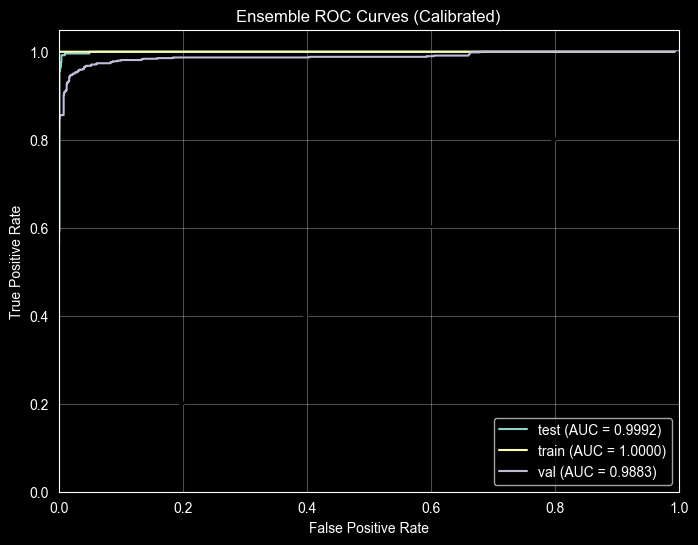

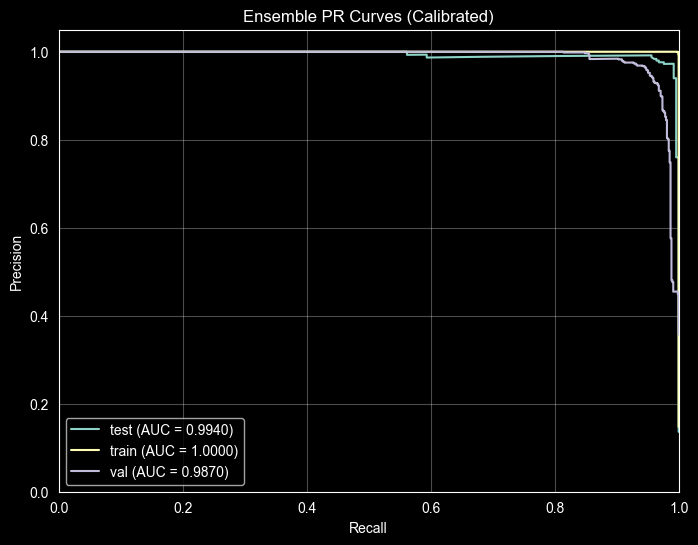

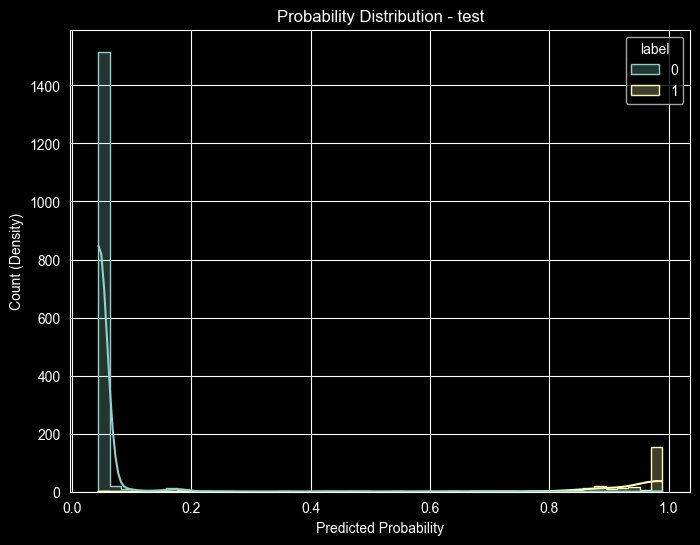

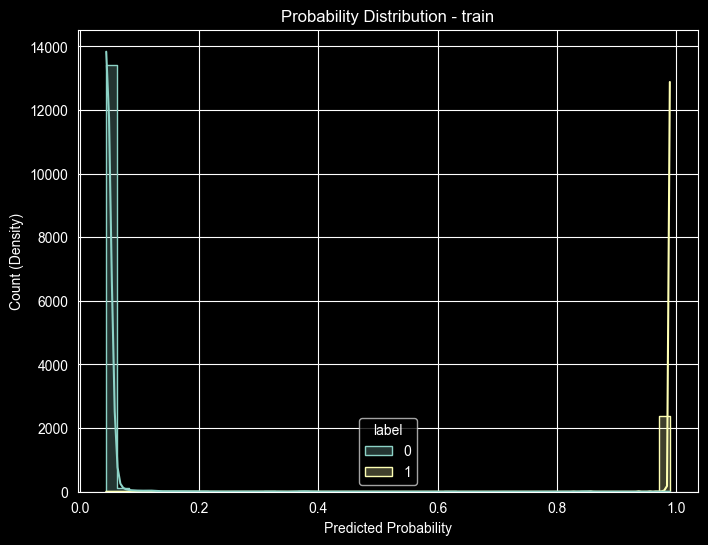

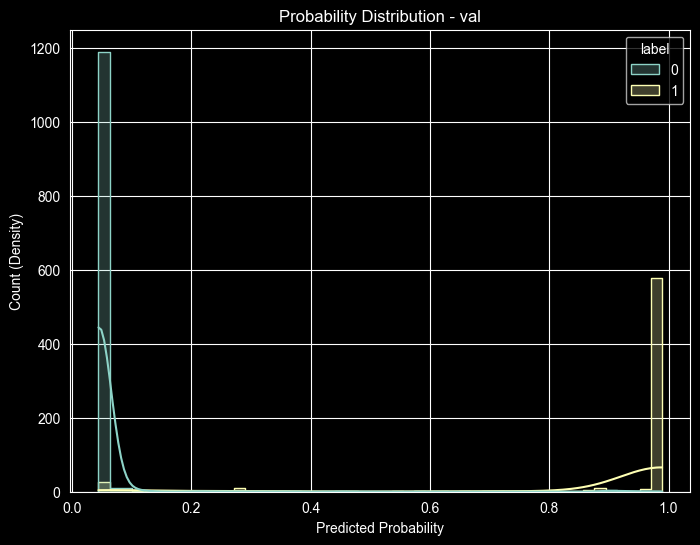

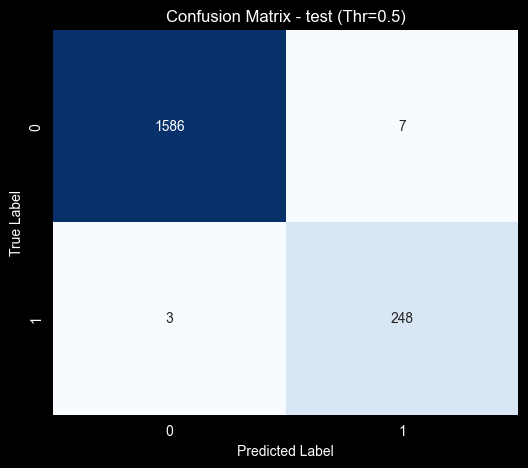

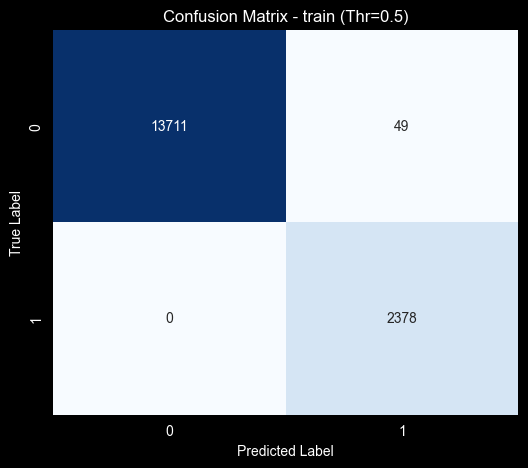

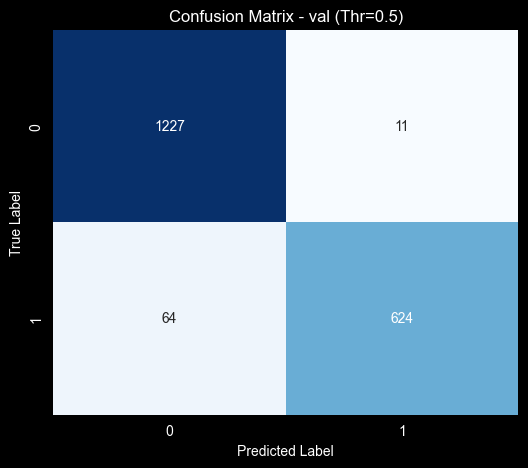

In [3]:
# 4. Visualization
print("\n--- Generating Plots for Ensemble ---")
plot_roc_curves(df_preds, prob_col="p_calib", title="Ensemble ROC Curves (Calibrated)")
plot_pr_curves(df_preds, prob_col="p_calib", title="Ensemble PR Curves (Calibrated)")
plot_probability_distributions(df_preds, prob_col="p_calib")
plot_confusion_matrices(df_preds, prob_col="p_calib", threshold=0.5)